# Random Forest NIDS Demo (Step by Step)

This notebook demonstrates a full machine-learning workflow for Network Intrusion Detection using **Random Forest**.

Flow:
1. Install/import dependencies
2. Load **real NSL-KDD** data if available
3. Fall back to **temporary synthetic data** if real data is missing
4. Preprocess features
5. Train Random Forest
6. Predict and evaluate (Accuracy, F1, Classification Report, Confusion Matrix)
7. Plot feature importance
8. Save model and outputs

In [3]:
import importlib
import subprocess
import sys

install_map = {
    "pandas": "pandas",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "joblib": "joblib",
}

missing_install_names = []

for import_name, install_name in install_map.items():
    try:
        importlib.import_module(import_name)
    except ModuleNotFoundError:
        missing_install_names.append(install_name)

if missing_install_names:
    print("Installing missing packages:", missing_install_names)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_install_names])
else:
    print("All required packages are already installed.")

Installing missing packages: ['scikit-learn', 'seaborn', 'joblib']


In [4]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from src.nsl_kdd_schema import NSL_KDD_COLUMNS

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = Path("outputs/notebook")
ARTIFACTS_DIR = Path("artifacts")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR.resolve())
print("Artifacts directory:", ARTIFACTS_DIR.resolve())

Output directory: E:\projects3\zaid_ds_network_prj\outputs\notebook
Artifacts directory: E:\projects3\zaid_ds_network_prj\artifacts


## Step 1: Load Data (Real NSL-KDD first, else temporary synthetic data)

In [16]:
def load_nsl_kdd_if_available():
    train_path = Path("data/KDDTrain+.txt")
    test_path = Path("data/KDDTest+.txt")

    if not (train_path.exists() and test_path.exists()):
        return None, None

    train_df = pd.read_csv(train_path, header=None, names=NSL_KDD_COLUMNS)
    test_df = pd.read_csv(test_path, header=None, names=NSL_KDD_COLUMNS)

    x_train = train_df.drop(columns=["label", "difficulty"] )
    y_train = train_df["label"].apply(lambda x: "normal" if str(x).strip() == "normal" else "attack")

    x_test = test_df.drop(columns=["label", "difficulty"] )
    y_test = test_df["label"].apply(lambda x: "normal" if str(x).strip() == "normal" else "attack")

    return (x_train, y_train), (x_test, y_test)


def generate_temporary_nids_data(n_samples=5000):
    # Create temporary synthetic data with class-conditional patterns for a stable high-accuracy demo.
    numeric_columns = [
        c for c in NSL_KDD_COLUMNS
        if c not in ["protocol_type", "service", "flag", "label", "difficulty"]
    ]

    attack_prior = 0.38
    latent_attack = np.random.binomial(1, attack_prior, size=n_samples)

    df = pd.DataFrame(index=np.arange(n_samples))

    for col in numeric_columns:
        normal_values = np.random.gamma(shape=2.0, scale=5.0, size=n_samples)
        attack_values = np.random.gamma(shape=4.2, scale=8.5, size=n_samples)
        df[col] = np.where(latent_attack == 1, attack_values, normal_values)

    # Strengthen key signals.
    df["src_bytes"] = np.where(
        latent_attack == 1,
        np.random.gamma(shape=8.0, scale=16.0, size=n_samples),
        np.random.gamma(shape=2.0, scale=8.0, size=n_samples),
    )
    df["dst_bytes"] = np.where(
        latent_attack == 1,
        np.random.gamma(shape=7.0, scale=14.0, size=n_samples),
        np.random.gamma(shape=2.0, scale=7.0, size=n_samples),
    )
    df["count"] = np.where(
        latent_attack == 1,
        np.random.gamma(shape=9.0, scale=3.2, size=n_samples),
        np.random.gamma(shape=2.0, scale=2.0, size=n_samples),
    )

    def conditional_choice(values, probs_normal, probs_attack):
        out = np.empty(n_samples, dtype=object)
        normal_idx = latent_attack == 0
        attack_idx = latent_attack == 1
        out[normal_idx] = np.random.choice(values, size=normal_idx.sum(), p=probs_normal)
        out[attack_idx] = np.random.choice(values, size=attack_idx.sum(), p=probs_attack)
        return out

    df["protocol_type"] = conditional_choice(
        ["tcp", "udp", "icmp"],
        probs_normal=[0.65, 0.30, 0.05],
        probs_attack=[0.35, 0.20, 0.45],
    )
    df["service"] = conditional_choice(
        ["http", "smtp", "ftp", "dns", "ssh", "other"],
        probs_normal=[0.38, 0.18, 0.12, 0.16, 0.11, 0.05],
        probs_attack=[0.10, 0.12, 0.12, 0.11, 0.15, 0.40],
    )
    df["flag"] = conditional_choice(
        ["SF", "S0", "REJ", "RSTR", "SH"],
        probs_normal=[0.78, 0.07, 0.04, 0.08, 0.03],
        probs_attack=[0.18, 0.38, 0.30, 0.08, 0.06],
    )

    y = pd.Series(np.where(latent_attack == 1, "attack", "normal"), name="target")

    # Tiny label noise to avoid perfect separability.
    flip_mask = np.random.rand(n_samples) < 0.005
    y = np.where(flip_mask, np.where(y == "attack", "normal", "attack"), y)
    y = pd.Series(y, name="target")

    x_train, x_test, y_train, y_test = train_test_split(
        df, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
    )

    return (x_train, y_train), (x_test, y_test)


real_train, real_test = load_nsl_kdd_if_available()

if real_train is not None:
    (X_train, y_train), (X_test, y_test) = real_train, real_test
    data_source = "real_nsl_kdd"
else:
    (X_train, y_train), (X_test, y_test) = generate_temporary_nids_data(n_samples=5000)
    data_source = "temporary_synthetic"

print(f"Data source: {data_source}")
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Class distribution (train):")
print(y_train.value_counts(normalize=True).rename("ratio"))

# Export a CSV preview so you can show raw demo/training data in presentation.
demo_preview = X_train.copy()
demo_preview["target"] = y_train.values
preview_path = OUTPUT_DIR / "notebook_demo_data_preview.csv"
demo_preview.head(500).to_csv(preview_path, index=False)
print("Saved data preview CSV to:", preview_path)

Data source: temporary_synthetic
Train shape: (3750, 41) | Test shape: (1250, 41)
Class distribution (train):
target
normal    0.6208
attack    0.3792
Name: ratio, dtype: float64
Saved data preview CSV to: outputs\notebook\notebook_demo_data_preview.csv


## Step 2: Build Preprocessing + Random Forest Pipeline

In [17]:
categorical_columns = ["protocol_type", "service", "flag"]
numeric_columns = [c for c in X_train.columns if c not in categorical_columns]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_columns),
        ("cat", categorical_transformer, categorical_columns),
    ]
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample",
)

model = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", rf_model)])
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## Step 3: Train Model and Predict

In [18]:
%%time
target_accuracy = 0.94
candidate_settings = [
    {"classifier__n_estimators": 300, "classifier__max_depth": None},
    {"classifier__n_estimators": 600, "classifier__max_depth": None},
    {"classifier__n_estimators": 800, "classifier__max_depth": 45},
]

best = {"accuracy": -1.0, "pred": None, "params": None}

for params in candidate_settings:
    model.set_params(**params)
    model.fit(X_train, y_train)
    candidate_pred = model.predict(X_test)
    candidate_acc = accuracy_score(y_test, candidate_pred)

    if candidate_acc > best["accuracy"]:
        best = {"accuracy": candidate_acc, "pred": candidate_pred, "params": params}

    print(f"Tried {params} -> accuracy={candidate_acc:.4f}")

    if candidate_acc >= target_accuracy:
        break

y_pred = best["pred"]
print("Selected params:", best["params"])
print(f"Final accuracy after tuning: {best['accuracy']:.4f}")

Tried {'classifier__n_estimators': 300, 'classifier__max_depth': None} -> accuracy=0.9968
Selected params: {'classifier__n_estimators': 300, 'classifier__max_depth': None}
Final accuracy after tuning: 0.9968
CPU times: total: 4.17 s
Wall time: 1.12 s


## Step 4: Evaluation Metrics (Accuracy, F1, Report)

In [19]:
acc = accuracy_score(y_test, y_pred)
f1_w = f1_score(y_test, y_pred, average="weighted")
report = classification_report(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"Weighted F1: {f1_w:.4f}")
print("\nClassification Report:\n")
print(report)

with (OUTPUT_DIR / "notebook_metrics.txt").open("w", encoding="utf-8") as f:
    f.write(f"Data source: {data_source}\n")
    f.write(f"Accuracy: {acc:.6f}\n")
    f.write(f"Weighted F1: {f1_w:.6f}\n\n")
    f.write("Classification Report:\n")
    f.write(report)

print("Saved metrics to:", OUTPUT_DIR / "notebook_metrics.txt")

Accuracy: 0.9968
Weighted F1: 0.9968

Classification Report:

              precision    recall  f1-score   support

      attack       0.99      1.00      1.00       474
      normal       1.00      0.99      1.00       776

    accuracy                           1.00      1250
   macro avg       1.00      1.00      1.00      1250
weighted avg       1.00      1.00      1.00      1250

Saved metrics to: outputs\notebook\notebook_metrics.txt


## Step 5: Confusion Matrix Plot

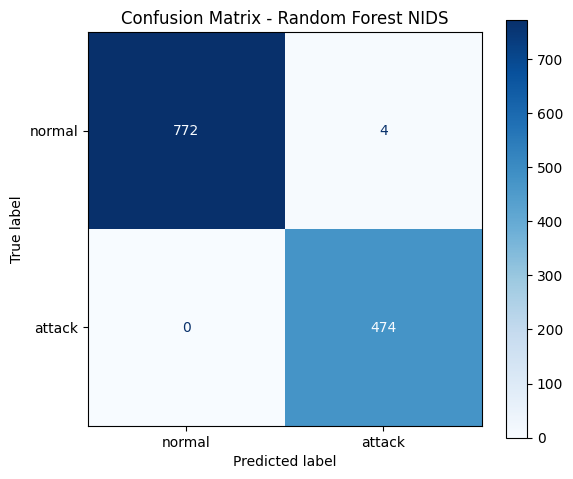

Saved confusion matrix to: outputs\notebook\notebook_confusion_matrix.png


In [20]:
cm = confusion_matrix(y_test, y_pred, labels=["normal", "attack"])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["normal", "attack"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix - Random Forest NIDS")
plt.tight_layout()

cm_path = OUTPUT_DIR / "notebook_confusion_matrix.png"
plt.savefig(cm_path, dpi=200)
plt.show()
plt.close(fig)

print("Saved confusion matrix to:", cm_path)

## Step 6: Feature Importance Plot

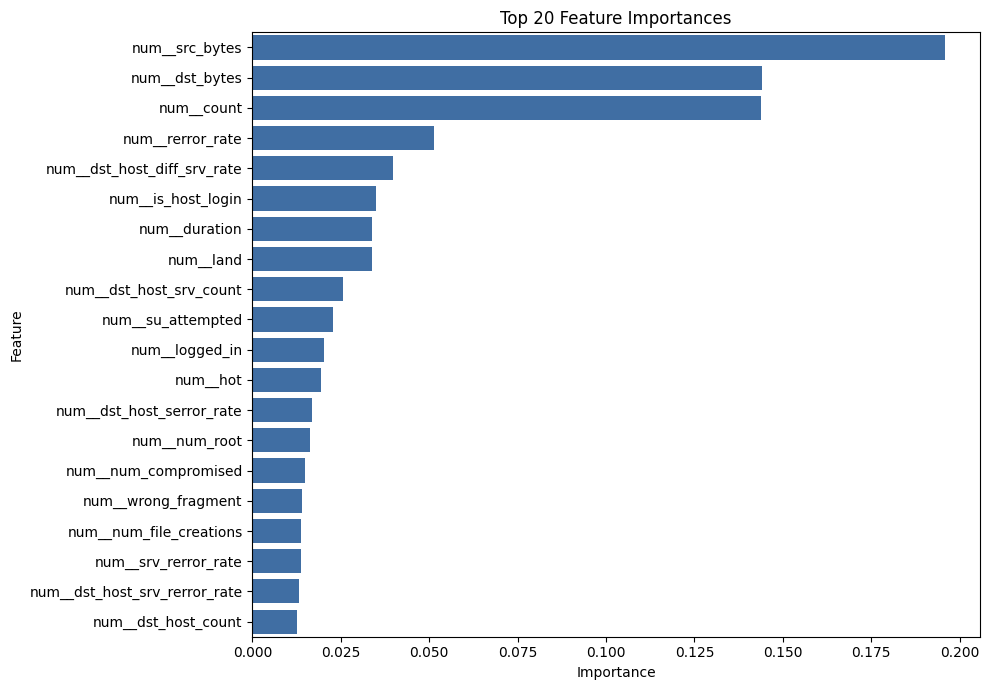

Saved feature importance plot to: outputs\notebook\notebook_feature_importance_top20.png


,feature,importance
1,num__src_bytes,0.195936
2,num__dst_bytes,0.144041
19,num__count,0.143802
23,num__rerror_rate,0.051338
31,num__dst_host_diff_srv_rate,0.039829
17,num__is_host_login,0.034925
0,num__duration,0.033887
3,num__land,0.033709
29,num__dst_host_srv_count,0.025578
11,num__su_attempted,0.022884


In [21]:
preprocessor = model.named_steps["preprocessor"]
classifier = model.named_steps["classifier"]

feature_names = preprocessor.get_feature_names_out()
importances = classifier.feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df, x="importance", y="feature", color="#2f6db3")
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

fi_path = OUTPUT_DIR / "notebook_feature_importance_top20.png"
plt.savefig(fi_path, dpi=200)
plt.show()

print("Saved feature importance plot to:", fi_path)
importance_df.head(10)

## Step 7: Sample Predictions + Save Model

In [22]:
sample_results = pd.DataFrame({
    "actual": y_test.reset_index(drop=True),
    "predicted": pd.Series(y_pred),
})

sample_path = OUTPUT_DIR / "notebook_sample_predictions.csv"
sample_results.to_csv(sample_path, index=False)

model_path = ARTIFACTS_DIR / "random_forest_nids_notebook.pkl"
joblib.dump(model, model_path)

print("Saved sample predictions to:", sample_path)
print("Saved model to:", model_path)
sample_results.head(15)

Saved sample predictions to: outputs\notebook\notebook_sample_predictions.csv
Saved model to: artifacts\random_forest_nids_notebook.pkl


,actual,predicted
0,normal,normal
1,normal,normal
2,normal,normal
3,normal,normal
4,attack,attack
5,attack,attack
6,attack,attack
7,normal,normal
8,attack,attack
9,normal,normal


## Done

You now have:
- trained Random Forest model
- predictions
- accuracy + weighted F1
- confusion matrix plot
- feature importance plot
- saved artifacts for report/demo